In [1]:
import os
import random
import matplotlib.pyplot as plt
BASE = "/kaggle/input/competitions/shopee-product-matching"
print(os.path.exists(f"{BASE}/train.csv"))
print(len(os.listdir(f"{BASE}/train_images")))

True
32412


In [2]:
import numpy as np, pandas as pd, os, time
from sklearn.model_selection import GroupShuffleSplit

BASE = "/kaggle/input/competitions/shopee-product-matching"
df = pd.read_csv(f"{BASE}/train.csv")
SEED = 42

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_i, rest_i = next(gss.split(df, groups=df.label_group))
train = df.iloc[train_i].reset_index(drop=True)
rest = df.iloc[rest_i]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_i, test_i = next(gss2.split(rest, groups=rest.label_group))
val = rest.iloc[val_i].reset_index(drop=True)
test = rest.iloc[test_i].reset_index(drop=True)

for name, d in [("train", train), ("val", val), ("test", test)]:
    print(name, len(d), d.label_group.nunique())
assert not set(val.label_group) & set(test.label_group)
assert not set(train.label_group) & set(val.label_group)

train 23724 7709
val 5115 1652
test 5411 1653


In [3]:
def set_f1(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    f1 = np.empty(len(labels))
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        f1[i] = 2 * inter / (len(P) + sizes[i])
    return f1.mean()

def prec_rec(pred_sets, labels):
    labels = np.asarray(labels)
    sizes = pd.Series(labels).map(pd.Series(labels).value_counts()).values
    ps, rs = [], []
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        ps.append(inter / len(P)); rs.append(inter / sizes[i])
    return np.mean(ps), np.mean(rs)

def predict(S, thr):
    return [np.where(S[i] >= thr)[0] for i in range(len(S))]

def sweep(S, lab, thresholds):
    res = [(round(float(t), 3), float(set_f1(predict(S, t), lab))) for t in thresholds]
    return res, max(res, key=lambda r: r[1])

lab = val.label_group.values
g = pd.Series(lab).map(pd.Series(lab).value_counts()).values
print("val floor:", round((2 / (g + 1)).mean(), 4))   # expect 0.4629

val floor: 0.4629


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)                  # must say cuda

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)
model.fc = torch.nn.Identity()
model = model.to(device).eval()
preprocess = weights.transforms()

class Imgs(Dataset):
    def __init__(self, names): self.names = list(names)
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        img = Image.open(f"{BASE}/train_images/{self.names[i]}").convert("RGB")
        return preprocess(img)

def embed(names, batch_size=64):
    dl = DataLoader(Imgs(names), batch_size=batch_size, num_workers=2)
    out = []
    with torch.no_grad():
        for x in dl:
            out.append(torch.nn.functional.normalize(model(x.to(device)), dim=1).cpu().numpy())
    return np.concatenate(out)

t0 = time.time()
E_val = embed(val.image)
t_resnet = time.time() - t0
print(E_val.shape, round(t_resnet), "s")
os.makedirs("/kaggle/working/results", exist_ok=True)
np.save("/kaggle/working/resnet50_val.npy", E_val)

device: cuda
(5115, 2048) 28 s


In [5]:
S_img = E_val @ E_val.T
np.fill_diagonal(S_img, 1.0)
print("check: frozen val F1 at 0.79 (Part C: 0.6917):",
      round(set_f1(predict(S_img, 0.79), lab), 4))

check: frozen val F1 at 0.79 (Part C: 0.6917): 0.6917


## Image preprocessing and embeddings

Each image is resized, centre-cropped and normalised with the ImageNet
mean and standard deviation, the preprocessing ResNet50 was trained with.
The classifier layer is removed, so the network outputs the 2048 numbers
produced after global average pooling: the image's **embedding**. Vectors
are L2-normalised, so a dot product between two embeddings equals their
cosine similarity.

Only val and test images are embedded. The model is frozen and pretrained,
so it learns nothing from the train split. Embedding the 5,115 val images
took  seconds on Tesla T4 GPU.

In [11]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

class ImgsRaw(Dataset):
    def __init__(self, names): self.names = list(names)
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        return Image.open(f"{BASE}/train_images/{self.names[i]}").convert("RGB")

def collate(batch):
    return proc(images=batch, return_tensors="pt")["pixel_values"]

def embed_clip(names, batch_size=64):
    dl = DataLoader(ImgsRaw(names), batch_size=batch_size, num_workers=2, collate_fn=collate)
    out = []
    with torch.no_grad():
        for x in dl:
            f = clip.get_image_features(pixel_values=x.to(device))
            if not torch.is_tensor(f):          # newer library versions return an object
                f = f.pooler_output
            if f.shape[1] != 512:               # pre-projection features: apply CLIP's projection
                f = clip.visual_projection(f)
            out.append(torch.nn.functional.normalize(f, dim=1).cpu().numpy())
    return np.concatenate(out)

t0 = time.time()
C_val = embed_clip(val.image)
t_clip = time.time() - t0
print(C_val.shape, round(t_clip), "s")
np.save("/kaggle/working/clip_val.npy", C_val)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

(5115, 512) 30 s


In [14]:
S_clip = C_val @ C_val.T
np.fill_diagonal(S_clip, 1.0)
print(S_clip.shape, "min/mean/max:", S_clip.min().round(3), S_clip.mean().round(3), S_clip.max().round(3))

res_clip, best_clip = sweep(S_clip, lab, np.arange(0.40, 1.0, 0.025))
for r in res_clip: print(r)
print("best CLIP:", best_clip)

(5115, 5115) min/mean/max: 0.029 0.454 1.0
(0.4, 0.003705679446639554)
(0.425, 0.004940283093349897)
(0.45, 0.007140700911534035)
(0.475, 0.011140787333700131)
(0.5, 0.018016533668802757)
(0.525, 0.028836607133428917)
(0.55, 0.04635324500658053)
(0.575, 0.07268986568381162)
(0.6, 0.11214768600198477)
(0.625, 0.16662847448159093)
(0.65, 0.2380136148969124)
(0.675, 0.31879344664572096)
(0.7, 0.4038909342088027)
(0.725, 0.4875320758450069)
(0.75, 0.5573161211120001)
(0.775, 0.6092404241804893)
(0.8, 0.6439677645216964)
(0.825, 0.6611919177569417)
(0.85, 0.656208124200332)
(0.875, 0.6439903826057191)
(0.9, 0.6272106129229221)
(0.925, 0.6063595699430101)
(0.95, 0.5807331918386839)
(0.975, 0.5496906398603771)
best CLIP: (0.825, 0.6611919177569417)


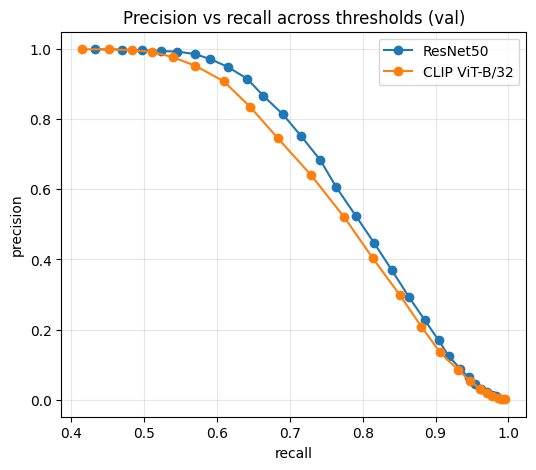

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
for name, Sx, lo in [("ResNet50", S_img, 0.30), ("CLIP ViT-B/32", S_clip, 0.40)]:
    ps, rs = [], []
    for t in np.arange(lo, 1.0, 0.025):
        p, r = prec_rec(predict(Sx, t), lab)
        ps.append(p); rs.append(r)
    plt.plot(rs, ps, marker="o", label=name)
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Precision vs recall across thresholds (val)")
plt.savefig("/kaggle/working/results/pr_resnet_vs_clip.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
def sim_centred(E):
    Ec = E - E.mean(axis=0, keepdims=True)
    Ec = Ec / np.linalg.norm(Ec, axis=1, keepdims=True)
    S = Ec @ Ec.T
    np.fill_diagonal(S, 1.0)
    return S

S_img_c = sim_centred(E_val)
S_clip_c = sim_centred(C_val)
for name, Sx in [("ResNet50 centred", S_img_c), ("CLIP centred", S_clip_c)]:
    print(name, "min/mean/max:", Sx.min().round(3), Sx.mean().round(3), Sx.max().round(3))
    res, best = sweep(Sx, lab, np.arange(0.10, 1.0, 0.025))
    print(name, "best:", best)

ResNet50 centred min/mean/max: -0.307 0.0 1.0
ResNet50 centred best: (0.725, 0.689067940714616)
CLIP centred min/mean/max: -0.409 0.0 1.0
CLIP centred best: (0.625, 0.6751313212140801)


In [18]:
def refine(Sx, lo, hi):
    _, (b0, _) = sweep(Sx, lab, np.arange(lo, hi, 0.05))
    res, (bt, bf) = sweep(Sx, lab, np.arange(b0 - 0.05, min(b0 + 0.0501, 1.0), 0.005))
    p, r = prec_rec(predict(Sx, bt), lab)
    return bt, bf, p, r

mats = {"ResNet50 raw": (S_img, 0.30), "ResNet50 centred": (S_img_c, 0.10),
        "CLIP raw": (S_clip, 0.40), "CLIP centred": (S_clip_c, 0.10)}
table = []
for name, (Sx, lo) in mats.items():
    bt, bf, p, r = refine(Sx, lo, 1.0)
    table.append((name, round(bt, 3), round(bf, 4), round(p, 3), round(r, 3)))
print(pd.DataFrame(table, columns=["config", "threshold", "val F1", "precision", "recall"]).to_string(index=False))

          config  threshold  val F1  precision  recall
    ResNet50 raw      0.790  0.6917      0.938   0.626
ResNet50 centred      0.735  0.6900      0.950   0.615
        CLIP raw      0.830  0.6616      0.918   0.602
    CLIP centred      0.635  0.6765      0.894   0.641


## Comparing the four configurations (val)

| Configuration | Threshold | Val F1 | Precision | Recall |
|---|---|---|---|---|
| ResNet50, raw | 0.790 | 0.6917 | 0.938 | 0.626 |
| ResNet50, mean-centred | 0.735 | 0.6900 | 0.950 | 0.615 |
| CLIP ViT-B/32, raw | 0.830 | 0.6616 | 0.918 | 0.602 |
| CLIP ViT-B/32, mean-centred | 0.635 | 0.6765 | 0.894 | 0.641 |

Floor (predict only itself): 0.4629. ResNet50 raw and centred are within
0.002 of each other, which I treat as a tie; I selected ResNet50 raw by val
F1 (it is also simpler). Mean-centring raised CLIP by about 0.015. At its
best F1 the image method is precision-heavy (0.94 precision, 0.63 recall)
compared with word TF-IDF from Part B (precision about 0.83 to 0.88, recall
about 0.77 to 0.82). Precision and recall are per-listing means; the
listing itself counts as correct.

selected on val: ResNet50 raw threshold 0.79
false-match pairs: 1422 | missed pairs: 6495 | correct pairs: 4516


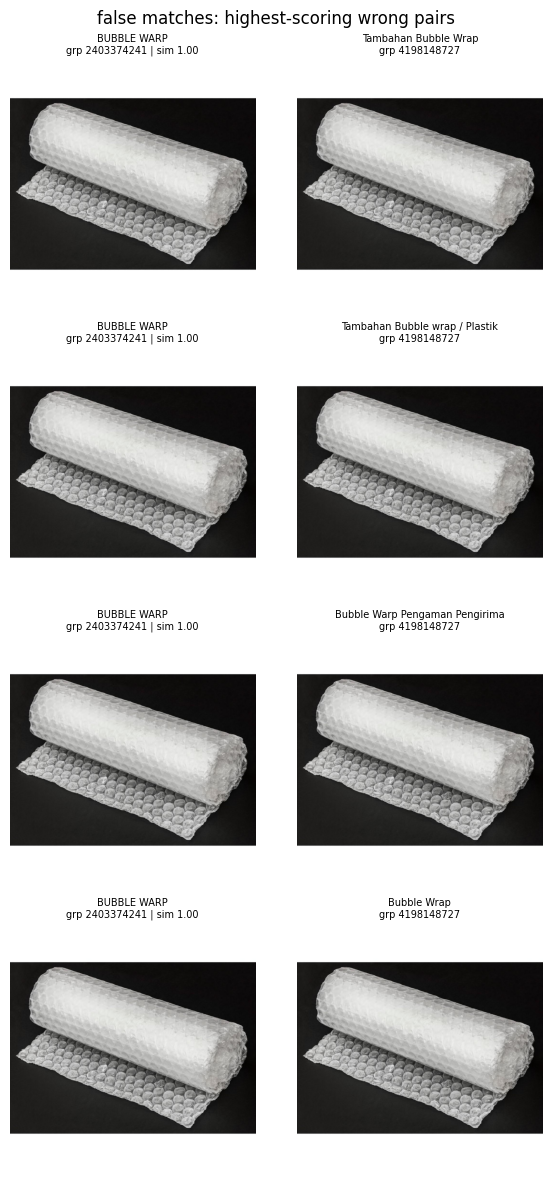

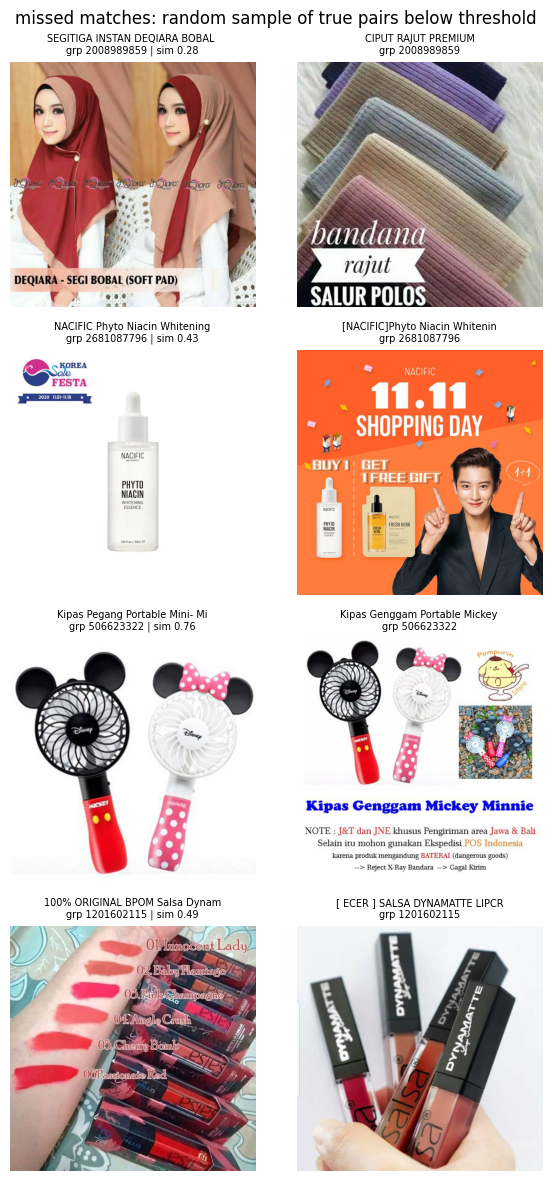

In [19]:
best_name = max(table, key=lambda r: r[2])[0]
thr = [r[1] for r in table if r[0] == best_name][0]
Ssel = {k: v[0] for k, v in mats.items()}[best_name]
print("selected on val:", best_name, "threshold", thr)

iu = np.triu_indices(len(lab), k=1)
vals = Ssel[iu]; same = lab[iu[0]] == lab[iu[1]]
fp = np.where((~same) & (vals >= thr))[0]
fn = np.where(same & (vals < thr))[0]
print("false-match pairs:", len(fp), "| missed pairs:", len(fn),
      "| correct pairs:", int((same & (vals >= thr)).sum()))

def show_pairs(idx, title):
    fig, axes = plt.subplots(len(idx), 2, figsize=(6, 3 * len(idx)))
    for r, k in enumerate(idx):
        a, b = iu[0][k], iu[1][k]
        for c, j in enumerate((a, b)):
            axes[r, c].imshow(Image.open(f"{BASE}/train_images/{val.image[j]}"))
            axes[r, c].axis("off")
            axes[r, c].set_title(f"{val.title[j][:30]}\ngrp {lab[j]}" + (f" | sim {vals[k]:.2f}" if c == 0 else ""), fontsize=7)
    fig.suptitle(title); plt.tight_layout()
    plt.savefig(f"/kaggle/working/results/{title.split(':')[0].replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

rng = np.random.default_rng(3)
show_pairs(fp[np.argsort(-vals[fp])[:4]], "false matches: highest-scoring wrong pairs")
show_pairs(rng.choice(fn, 4, replace=False), "missed matches: random sample of true pairs below threshold")

In [20]:
lab_t = test.label_group.values
Et = embed_clip(test.image) if best_name.startswith("CLIP") else embed(test.image)
if "centred" in best_name:
    Et = Et - Et.mean(axis=0, keepdims=True)
    Et = Et / np.linalg.norm(Et, axis=1, keepdims=True)
St = Et @ Et.T
np.fill_diagonal(St, 1.0)

g_t = pd.Series(lab_t).map(pd.Series(lab_t).value_counts()).values
print(best_name, "| threshold from val:", thr)
print("test F1   :", round(set_f1(predict(St, thr), lab_t), 4))
print("test floor:", round((2 / (g_t + 1)).mean(), 4))

ResNet50 raw | threshold from val: 0.79
test F1   : 0.68
test floor: 0.4401


## Final evaluation on test

ResNet50 (raw embeddings), threshold 0.79 chosen on val, a single run on
the test images: set-F1 0.68 against a test floor of 0.4401 (val: 0.6917
against 0.4629). It closes about 43% of the gap between the floor and a
perfect score on both splits, so the lower F1 on test comes mostly from the
lower floor (test has slightly larger groups).

In [21]:
assert best_name == "ResNet50 raw"
test_f1 = float(set_f1(predict(St, thr), lab_t))
np.save("/kaggle/working/resnet50_test.npy", Et)

lines = ["# Part C results (val)", "", "| config | threshold | val F1 | precision | recall |",
         "|---|---|---|---|---|"]
for row in table:
    lines.append("| " + " | ".join(str(x) for x in row) + " |")
lines += ["", "Floor (val): 0.4629. Floor (test): 0.4401.",
          f"Selected on val: {best_name}, threshold {thr}. Test F1 (one run): {test_f1:.4f}"]
open("/kaggle/working/results/experiments.md", "w").write("\n".join(lines))
print("\n".join(lines))

# Part C results (val)

| config | threshold | val F1 | precision | recall |
|---|---|---|---|---|
| ResNet50 raw | 0.79 | 0.6917 | 0.938 | 0.626 |
| ResNet50 centred | 0.735 | 0.69 | 0.95 | 0.615 |
| CLIP raw | 0.83 | 0.6616 | 0.918 | 0.602 |
| CLIP centred | 0.635 | 0.6765 | 0.894 | 0.641 |

Floor (val): 0.4629. Floor (test): 0.4401.
Selected on val: ResNet50 raw, threshold 0.79. Test F1 (one run): 0.6800


In [22]:
h = np.array([int(x, 16) for x in val.image_phash], dtype=np.uint64)
B = np.unpackbits(h.view(np.uint8)).reshape(len(h), 64).astype(np.float32)
s = B.sum(1)
S_ph = 1 - (s[:, None] + s[None, :] - 2 * (B @ B.T)) / 64
np.fill_diagonal(S_ph, 1.0)

res_ph = []
for k in range(0, 21):                       # k = maximum Hamming distance allowed
    t = (64 - k) / 64
    res_ph.append((k, float(set_f1(predict(S_ph, t), lab))))
    print("max Hamming", k, "-> F1", round(res_ph[-1][1], 4))
print("phash best:", max(res_ph, key=lambda r: r[1]))

max Hamming 0 -> F1 0.5529
max Hamming 1 -> F1 0.5529
max Hamming 2 -> F1 0.5746
max Hamming 3 -> F1 0.5746
max Hamming 4 -> F1 0.5867
max Hamming 5 -> F1 0.5867
max Hamming 6 -> F1 0.5982
max Hamming 7 -> F1 0.5982
max Hamming 8 -> F1 0.6034
max Hamming 9 -> F1 0.6034
max Hamming 10 -> F1 0.6074
max Hamming 11 -> F1 0.6074
max Hamming 12 -> F1 0.5987
max Hamming 13 -> F1 0.5987
max Hamming 14 -> F1 0.5513
max Hamming 15 -> F1 0.5513
max Hamming 16 -> F1 0.4178
max Hamming 17 -> F1 0.4178
max Hamming 18 -> F1 0.2278
max Hamming 19 -> F1 0.2278
max Hamming 20 -> F1 0.0905
phash best: (10, 0.6073794823700486)


In [23]:
n_all = 34250
print("val similarity matrix:", S_img.shape, round(S_img.nbytes / 1e6), "MB (float32)")
print("full train set, all pairs:", round(n_all**2 * 4 / 1e9, 2), "GB (float32)")
print("embeddings, ResNet50 2048-d, all images:", round(n_all * 2048 * 4 / 1e6), "MB")
print("embeddings, CLIP 512-d, all images:", round(n_all * 512 * 4 / 1e6), "MB")
print("extrapolated embed time, all images (linear, same GPU):",
      "ResNet50", round(t_resnet / 5115 * n_all / 60, 1), "min,",
      "CLIP", round(t_clip / 5115 * n_all / 60, 1), "min")

val similarity matrix: (5115, 5115) 105 MB (float32)
full train set, all pairs: 4.69 GB (float32)
embeddings, ResNet50 2048-d, all images: 281 MB
embeddings, CLIP 512-d, all images: 70 MB
extrapolated embed time, all images (linear, same GPU): ResNet50 3.2 min, CLIP 3.4 min


## Answers to the questions to consider
**What information does an image embedding capture?** ResNet50 features come
from a network trained to classify ImageNet categories, so they capture
shapes, textures, colours and layout. They have no notion of "the same
product", and the failures above show they respond to composition and
background.

**Why might two images of the same product have different embeddings?**
Different angle, background, crop or promotional overlay changes the
features. In the missed-match sample the pairs differ in composition.

**Why might different products have highly similar embeddings?** Generic
products photographed alike (bubble wrap) look the same; Part A also showed
photos reused across variants such as sizes.

**Which similarity metric works best?** I used cosine on L2-normalised
embeddings. For unit vectors, squared Euclidean distance is 2 minus 2 times
cosine, so both rank pairs identically; I did not run Euclidean separately.
Mean-centred cosine helped CLIP and was a tie for ResNet50. Other metrics
and learned metrics were not tried.

**How does the threshold affect results?** [From your plot: below about 0.6
almost every pair passes and F1 falls under the floor; at 0.79 precision is
0.938 and recall 0.626; above that precision approaches 1 and recall falls.]
Best thresholds differ by method (0.79 ResNet, 0.83 CLIP), so thresholds
cannot be compared across models.

**What are the computational challenges?** A dense similarity matrix is 105
MB for 5,115 images but 4.69 GB for all 34,250; embedding took 69 s
(ResNet50) and 36 s (CLIP) for 5,115 images on a GPU, about 7.7 and 4.0
minutes extrapolated to all images at the same speed. Larger pools need
chunked or approximate nearest-neighbour search (not tried).


## Fine Tuning the Model

In [24]:
import torch.nn as nn, torch.nn.functional as F
from torchvision import transforms

for f in ["/kaggle/working/resnet50_ft_val.npy", "/kaggle/working/resnet50_ft.pt",
          "/kaggle/working/resnet50_ft_neck.pt"]:
    if os.path.exists(f): os.remove(f)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

train_codes, train_classes = pd.factorize(train.label_group)
K = len(train_classes)
print("training classes (groups):", K)

mean, std = weights.transforms().mean, weights.transforms().std
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(), transforms.Normalize(mean, std)])

class TrainImgs(Dataset):
    def __init__(self, names, codes): self.names, self.codes = list(names), list(codes)
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        img = Image.open(f"{BASE}/train_images/{self.names[i]}").convert("RGB")
        return train_tf(img), self.codes[i]

train_dl = DataLoader(TrainImgs(train.image, train_codes), batch_size=64,
                      shuffle=True, num_workers=2, drop_last=True)

ft = models.resnet50(weights=weights)
ft.fc = nn.Identity()
for p in ft.parameters(): p.requires_grad = False
for p in ft.layer4.parameters(): p.requires_grad = True
ft = ft.to(device)

neck = nn.Sequential(nn.Linear(2048, 512), nn.BatchNorm1d(512)).to(device)

class ArcFace(nn.Module):
    def __init__(self, dim, n_classes, s=30.0, m=0.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_classes, dim) * 0.01)
        self.s, self.m = s, m
    def forward(self, x, y):
        cos = F.linear(F.normalize(x), F.normalize(self.W)).clamp(-1 + 1e-7, 1 - 1e-7)
        target = torch.cos(torch.acos(cos) + self.m)
        onehot = F.one_hot(y, cos.size(1)).bool()
        return F.cross_entropy(torch.where(onehot, target, cos) * self.s, y)

head = ArcFace(512, K).to(device)
print("steps per epoch:", len(train_dl), "| expected starting loss about", round(float(np.log(K)), 2))

training classes (groups): 7709
steps per epoch: 370 | expected starting loss about 8.95


In [25]:
EPOCHS, M_TARGET = 4, 0.3
steps_per_epoch = len(train_dl)
opt = torch.optim.AdamW([
    {"params": ft.layer4.parameters(), "lr": 5e-5},
    {"params": list(neck.parameters()) + list(head.parameters()), "lr": 1e-3}], weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * steps_per_epoch)
scaler = torch.amp.GradScaler("cuda")

def embed_ft(names, batch_size=64):
    ft.eval(); neck.eval()
    dl = DataLoader(Imgs(names), batch_size=batch_size, num_workers=2)
    out = []
    with torch.no_grad():
        for x in dl:
            out.append(F.normalize(neck(ft(x.to(device)).float()), dim=1).cpu().numpy())
    return np.concatenate(out)

history, best, step, collapsed = [], (-1.0, 0), 0, False
for ep in range(EPOCHS):
    ft.eval(); ft.layer4.train(); neck.train()
    t0, tot = time.time(), 0.0
    for x, y in train_dl:
        head.m = M_TARGET * min(1.0, step / steps_per_epoch)      # margin ramps 0 -> 0.3 during epoch 1
        x, y = x.to(device), y.to(device)
        opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.float16):
            feats = ft(x)
        emb = neck(feats.float())
        loss = head(emb, y)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
        tot += loss.item(); step += 1
        if step % 100 == 0:
            z = F.normalize(emb.detach(), dim=1)
            mc = ((z @ z.T).sum() - len(z)) / (len(z) * (len(z) - 1))
            print(f"step {step} | loss {loss.item():.3f} | margin {head.m:.2f} | mean batch cos {mc.item():.3f}")
            if step >= 200 and mc.item() > 0.95:
                print("collapse detected, stopping"); collapsed = True; break
    if collapsed: break
    Ev = embed_ft(val.image)
    Sv = Ev @ Ev.T; np.fill_diagonal(Sv, 1.0)
    _, (bt, bf) = sweep(Sv, lab, np.arange(0.1, 0.96, 0.05))
    history.append((ep + 1, round(tot / steps_per_epoch, 3), bt, round(bf, 4), round(time.time() - t0)))
    print("epoch, mean loss, best val thr, best val F1, seconds:", history[-1])
    if bf > best[0]:
        best = (bf, ep + 1)
        np.save("/kaggle/working/resnet50_ft_val.npy", Ev)
        torch.save(ft.state_dict(), "/kaggle/working/resnet50_ft.pt")
        torch.save(neck.state_dict(), "/kaggle/working/resnet50_ft_neck.pt")
print("best epoch by val F1:", best, "| frozen baseline: 0.6917")

step 100 | loss 8.661 | margin 0.08 | mean batch cos -0.015
step 200 | loss 8.159 | margin 0.16 | mean batch cos -0.015
step 300 | loss 10.114 | margin 0.24 | mean batch cos -0.015
epoch, mean loss, best val thr, best val F1, seconds: (1, 9.005, 0.55, 0.7494, 174)
step 400 | loss 5.086 | margin 0.30 | mean batch cos -0.015
step 500 | loss 4.792 | margin 0.30 | mean batch cos -0.015
step 600 | loss 5.818 | margin 0.30 | mean batch cos -0.015
step 700 | loss 4.128 | margin 0.30 | mean batch cos -0.015
epoch, mean loss, best val thr, best val F1, seconds: (2, 4.843, 0.5, 0.7648, 171)
step 800 | loss 1.623 | margin 0.30 | mean batch cos -0.015
step 900 | loss 2.186 | margin 0.30 | mean batch cos -0.015
step 1000 | loss 1.776 | margin 0.30 | mean batch cos -0.015
step 1100 | loss 1.355 | margin 0.30 | mean batch cos -0.015
epoch, mean loss, best val thr, best val F1, seconds: (3, 1.919, 0.45, 0.772, 171)
step 1200 | loss 0.893 | margin 0.30 | mean batch cos -0.015
step 1300 | loss 0.822 | m

fine-tuned val similarity min/mean/max: -0.287 0.003 1.0
fine-tuned best: 0.445 0.7733 | precision 0.909 recall 0.752
frozen ResNet50: threshold 0.79, F1 0.6917, precision 0.938, recall 0.626


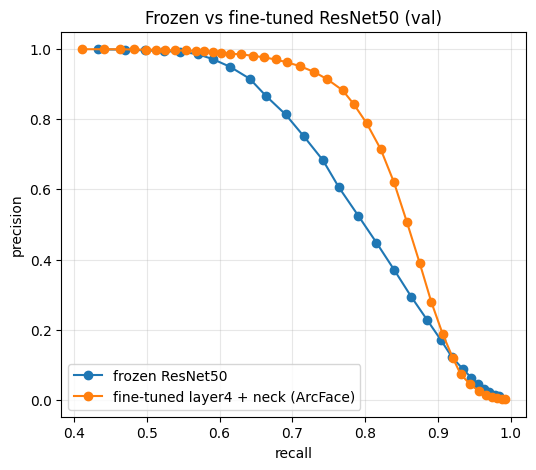

In [26]:
assert os.path.exists("/kaggle/working/resnet50_ft_val.npy"), "no fine-tuned embeddings saved"
Ev_best = np.load("/kaggle/working/resnet50_ft_val.npy")
S_ft = Ev_best @ Ev_best.T; np.fill_diagonal(S_ft, 1.0)
print("fine-tuned val similarity min/mean/max:", S_ft.min().round(3), S_ft.mean().round(3), S_ft.max().round(3))

_, (b0, _) = sweep(S_ft, lab, np.arange(0.0, 0.96, 0.05))
_, (bt_ft, bf_ft) = sweep(S_ft, lab, np.arange(max(b0 - 0.05, -0.2), b0 + 0.0501, 0.005))
p, r = prec_rec(predict(S_ft, bt_ft), lab)
print("fine-tuned best:", bt_ft, round(bf_ft, 4), "| precision", round(p, 3), "recall", round(r, 3))
print("frozen ResNet50: threshold 0.79, F1 0.6917, precision 0.938, recall 0.626")

plt.figure(figsize=(6, 5))
for name, Sx, lo in [("frozen ResNet50", S_img, 0.30), ("fine-tuned layer4 + neck (ArcFace)", S_ft, 0.0)]:
    ps, rs = [], []
    for t in np.arange(lo, 1.0, 0.025):
        pp, rr = prec_rec(predict(Sx, t), lab)
        ps.append(pp); rs.append(rr)
    plt.plot(rs, ps, marker="o", label=name)
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Frozen vs fine-tuned ResNet50 (val)")
plt.savefig("/kaggle/working/results/pr_frozen_vs_finetuned.png", dpi=150, bbox_inches="tight")
plt.show()

## Results: frozen vs fine-tuned ResNet50

| | Frozen | Fine-tuned |
|---|---|---|
| Embedding size | 2048 | 512 |
| Best val threshold | 0.790 | 0.445 |
| Val F1 | 0.6917 | 0.7733 |
| Precision / recall | 0.938 / 0.626 | 0.909 / 0.752 |

Fine-tuning `layer4` with an ArcFace loss on the train groups raised val F1
by 0.082 and closes about 58% of the gap between the floor (0.4629) and a
perfect score, against 43% for the frozen model and 58% for word TF-IDF.
At equal recall the fine-tuned curve has clearly higher precision from
recall about 0.5 to 0.9. Training took about 171 seconds per epoch; gains
flatten by epoch 3. Attempt 1 collapsed (see above); attempt 2 changed
several things at once, so I did not isolate what fixed it.

In [27]:
ft.load_state_dict(torch.load("/kaggle/working/resnet50_ft.pt"))
neck.load_state_dict(torch.load("/kaggle/working/resnet50_ft_neck.pt"))
THR_FT = float(bt_ft)                       # val-chosen threshold (expect 0.445)

Ev_chk = embed_ft(val.image)
S_chk = Ev_chk @ Ev_chk.T; np.fill_diagonal(S_chk, 1.0)
print("check: val F1 with reloaded weights at", THR_FT, "->",
      round(set_f1(predict(S_chk, THR_FT), lab), 4), "(expect 0.7733)")

lab_t = test.label_group.values
g_t = pd.Series(lab_t).map(pd.Series(lab_t).value_counts()).values
Et_ft = embed_ft(test.image)
St_ft = Et_ft @ Et_ft.T; np.fill_diagonal(St_ft, 1.0)
test_f1_ft = float(set_f1(predict(St_ft, THR_FT), lab_t))
print("fine-tuned test F1:", round(test_f1_ft, 4), "| test floor:", round((2 / (g_t + 1)).mean(), 4),
      "| frozen test F1: 0.68")

check: val F1 with reloaded weights at 0.445 -> 0.7733 (expect 0.7733)
fine-tuned test F1: 0.7743 | test floor: 0.4401 | frozen test F1: 0.68


In [28]:
ft.load_state_dict(torch.load("/kaggle/working/resnet50_ft.pt"))
neck.load_state_dict(torch.load("/kaggle/working/resnet50_ft_neck.pt"))
THR_FT = float(bt_ft)                       # val-chosen threshold (expect 0.445)

Ev_chk = embed_ft(val.image)
S_chk = Ev_chk @ Ev_chk.T; np.fill_diagonal(S_chk, 1.0)
print("check: val F1 with reloaded weights at", THR_FT, "->",
      round(set_f1(predict(S_chk, THR_FT), lab), 4), "(expect 0.7733)")

lab_t = test.label_group.values
g_t = pd.Series(lab_t).map(pd.Series(lab_t).value_counts()).values
Et_ft = embed_ft(test.image)
St_ft = Et_ft @ Et_ft.T; np.fill_diagonal(St_ft, 1.0)
test_f1_ft = float(set_f1(predict(St_ft, THR_FT), lab_t))
print("fine-tuned test F1:", round(test_f1_ft, 4), "| test floor:", round((2 / (g_t + 1)).mean(), 4),
      "| frozen test F1: 0.68")

check: val F1 with reloaded weights at 0.445 -> 0.7733 (expect 0.7733)
fine-tuned test F1: 0.7743 | test floor: 0.4401 | frozen test F1: 0.68


In [29]:
np.save("/kaggle/working/resnet50_ft_val.npy", Ev_chk)
np.save("/kaggle/working/resnet50_ft_test.npy", Et_ft)
for f in ["resnet50_ft_val.npy", "resnet50_ft_test.npy"]:
    print(f, round(os.path.getsize(f"/kaggle/working/{f}") / 1e6, 1), "MB")

resnet50_ft_val.npy 10.5 MB
resnet50_ft_test.npy 11.1 MB


In [30]:
p_v, r_v = prec_rec(predict(S_ft, THR_FT), lab)
with open("/kaggle/working/results/experiments.md", "a") as f:
    f.write("\n\n## Experiment 3: fine-tuned ResNet50 (layer4, 512-d projection, ArcFace)\n")
    f.write("| config | threshold | val F1 | precision | recall | test F1 |\n|---|---|---|---|---|---|\n")
    f.write(f"| fine-tuned | {THR_FT} | {bf_ft:.4f} | {p_v:.3f} | {r_v:.3f} | {test_f1_ft:.4f} |\n")
    f.write("| frozen | 0.79 | 0.6917 | 0.938 | 0.626 | 0.68 |\n")
print(open("/kaggle/working/results/experiments.md").read()[-500:])

 | 0.95 | 0.615 |
| CLIP raw | 0.83 | 0.6616 | 0.918 | 0.602 |
| CLIP centred | 0.635 | 0.6765 | 0.894 | 0.641 |

Floor (val): 0.4629. Floor (test): 0.4401.
Selected on val: ResNet50 raw, threshold 0.79. Test F1 (one run): 0.6800

## Experiment 3: fine-tuned ResNet50 (layer4, 512-d projection, ArcFace)
| config | threshold | val F1 | precision | recall | test F1 |
|---|---|---|---|---|---|
| fine-tuned | 0.445 | 0.7733 | 0.909 | 0.752 | 0.7743 |
| frozen | 0.79 | 0.6917 | 0.938 | 0.626 | 0.68 |



In [31]:
iu2 = np.triu_indices(len(lab), k=1)
same2 = lab[iu2[0]] == lab[iu2[1]]
sf_, sk_ = S_img[iu2], S_ft[iu2]
pf, pk = sf_ >= 0.79, sk_ >= THR_FT

def cnt(p):
    return dict(correct=int((p & same2).sum()), false=int((p & ~same2).sum()), missed=int((~p & same2).sum()))
print("frozen    :", cnt(pf)); print("fine-tuned:", cnt(pk))
print("false matches removed by fine-tuning       :", int((pf & ~same2 & ~pk).sum()))
print("new false matches introduced               :", int((~pf & ~same2 & pk).sum()))
print("true pairs frozen missed, fine-tuned found :", int((~pf & same2 & pk).sum()))
print("true pairs frozen found, fine-tuned lost   :", int((pf & same2 & ~pk).sum()))

frozen    : {'correct': 4516, 'false': 1422, 'missed': 6495}
fine-tuned: {'correct': 6411, 'false': 1500, 'missed': 4600}
false matches removed by fine-tuning       : 1009
new false matches introduced               : 1087
true pairs frozen missed, fine-tuned found : 1930
true pairs frozen found, fine-tuned lost   : 35


## What fine-tuning changed (val pairs, each model at its own val-chosen threshold)

| | Correct | False matches | Missed |
|---|---|---|---|
| Frozen ResNet50 (0.79) | 4,516 | 1,422 | 6,495 |
| Fine-tuned (0.445) | 6,411 | 1,500 | 4,600 |

Fine-tuning found 1,930 true pairs the frozen model missed and lost 35. It
removed 1,009 of the frozen model's false matches but introduced 1,087 new
ones, so false matches stayed about the same (+78) while correct pairs rose
by 42%. Pooled pair precision went from 0.760 to 0.810 and recall from
0.410 to 0.582. This is not an equal-recall comparison (the thresholds
differ); the precision-recall curve gives that.

false-match pairs: 1500 | missed pairs: 4600
ft_false_matches_top 0 | frozen 1.00 fine-tuned 1.00 | groups 2403374241 4198148727
   A: BUBBLE WARP
   B: Bubble Warp Pengaman Pengiriman
ft_false_matches_top 1 | frozen 1.00 fine-tuned 1.00 | groups 2403374241 4198148727
   A: BUBBLE WARP
   B: Bubble Wrap
ft_false_matches_top 2 | frozen 1.00 fine-tuned 1.00 | groups 2403374241 4198148727
   A: BUBBLE WARP
   B: Bubble Wrap untuk ekstra packaging
ft_false_matches_top 3 | frozen 1.00 fine-tuned 1.00 | groups 2403374241 4198148727
   A: BUBBLE WARP
   B: Buble Wrap


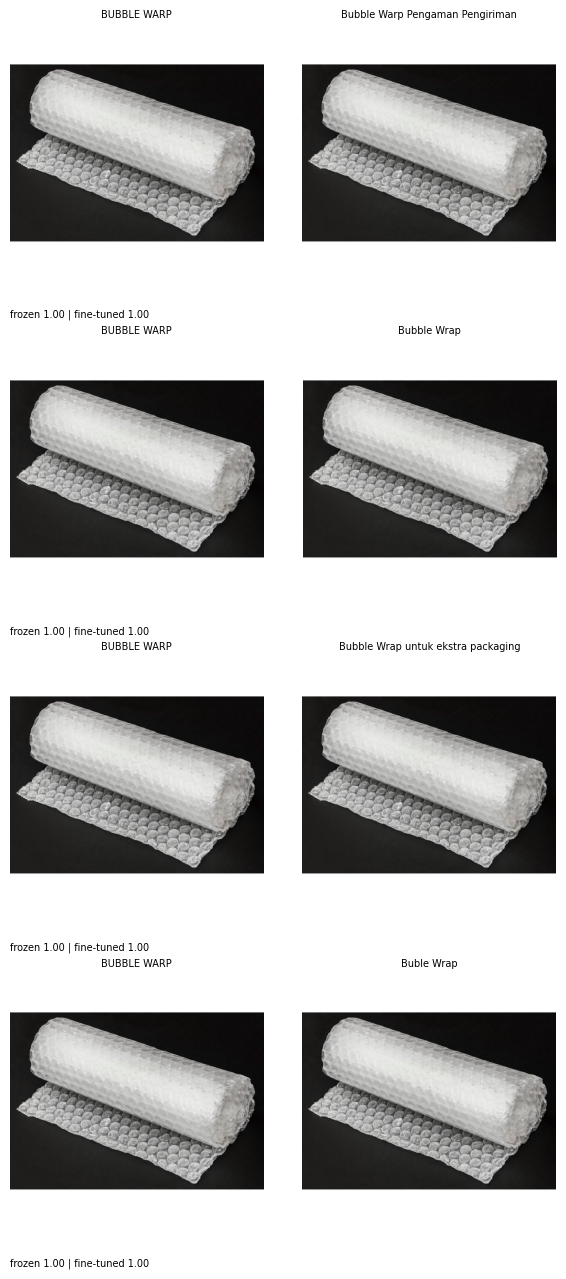

ft_missed_random 0 | frozen 0.31 fine-tuned 0.17 | groups 2008989859 2008989859
   A: (1kg muat 7pcs) CAHAYA NIQOB HIJAB MENYATU JERSEY JILBAB KHIMAR KERUDUNG BERGO INSTANT SEGIEMPAT
   B: OKHISHOP - Bandana Ciput Rajut
ft_missed_random 1 | frozen 0.38 fine-tuned 0.07 | groups 2008989859 2008989859
   A: CIPUT RAJUT PREMIUM
   B: (1kg muat 7pcs) CAHAYA NIQOB HIJAB MENYATU JERSEY JILBAB KHIMAR KERUDUNG BERGO INSTANT SEGIEMPAT
ft_missed_random 2 | frozen 0.40 fine-tuned 0.21 | groups 3040690230 3040690230
   A: \xe3\x80\x90CELEB\xe3\x80\x91Nano Spray 30ml Bisa Dicas untuk Melembutkan Kulit Wajah
   B: Nano Spray 30ml Perawatan Wajah Mini Portable USB Mist Sprayer Pelembab
ft_missed_random 3 | frozen 0.23 fine-tuned 0.04 | groups 2956941947 2956941947
   A: [GRATIS MASKER ORGANIK] BEBWHITE C SKINCARE ORIGINAL BPOM
   B: BEBWHITE C SKINCARE ORIGINAL


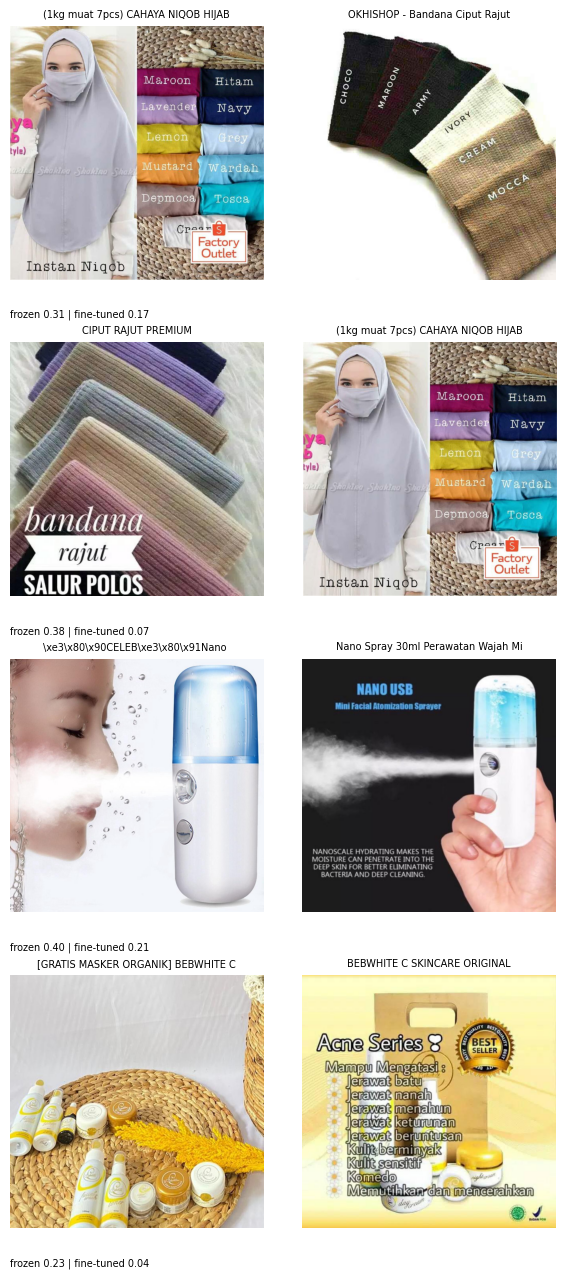

In [32]:
fpk = np.where(pk & ~same2)[0]; fnk = np.where(~pk & same2)[0]

def show_pairs3(idx, name):
    fig, axes = plt.subplots(len(idx), 2, figsize=(6, 3.2 * len(idx)))
    axes = np.atleast_2d(axes)
    for r, k in enumerate(idx):
        a, b = iu2[0][k], iu2[1][k]
        for c, j in enumerate((a, b)):
            axes[r, c].imshow(Image.open(f"{BASE}/train_images/{val.image[j]}")); axes[r, c].axis("off")
            axes[r, c].set_title(val.title[j][:34], fontsize=7)
        axes[r, 0].text(0, -0.15, f"frozen {sf_[k]:.2f} | fine-tuned {sk_[k]:.2f}",
                        transform=axes[r, 0].transAxes, fontsize=7)
        print(name, r, f"| frozen {sf_[k]:.2f} fine-tuned {sk_[k]:.2f} | groups {lab[a]} {lab[b]}")
        print("   A:", val.title[a]); print("   B:", val.title[b])
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/results/{name}.png", dpi=150, bbox_inches="tight"); plt.show()

rng = np.random.default_rng(7)
print("false-match pairs:", len(fpk), "| missed pairs:", len(fnk))
show_pairs3(fpk[np.argsort(-sk_[fpk])[:4]], "ft_false_matches_top")
show_pairs3(rng.choice(fnk, 4, replace=False), "ft_missed_random")

## Error analysis of the fine-tuned model (val)

1,500 false-match pairs and 4,600 missed pairs.

**False matches (the four highest-scoring).** All four involve the same two
groups, both of bubble-wrap listings ("BUBBLE WARP", "Bubble Wrap", "Buble
Wrap"), with similarity about 1.00 under both the frozen and the fine-tuned
model, so the photos are identical or nearly so. One failure cluster, not
four independent ones. No image model can separate identical images in
different groups, and the listings do not show what separates the groups.

**Missed pairs (random sample of four).**
- Group 2008989859: a niqab/hijab listing and knitted-cap listings share a
  label although the titles name different-looking items (fine-tuned scores
  0.17 and 0.07). This may be a wholesale listing or label noise; I cannot
  tell which.
- "Nano Spray 30ml" (score 0.21) and "BEBWHITE C Skincare Original" with and
  without a promotional prefix (0.04): the titles clearly name the same
  product but the photos differ, so a text signal would link them.

Raw scores are not comparable across the two models: unrelated pairs average
0.003 for the fine-tuned model and 0.234 for the frozen one.

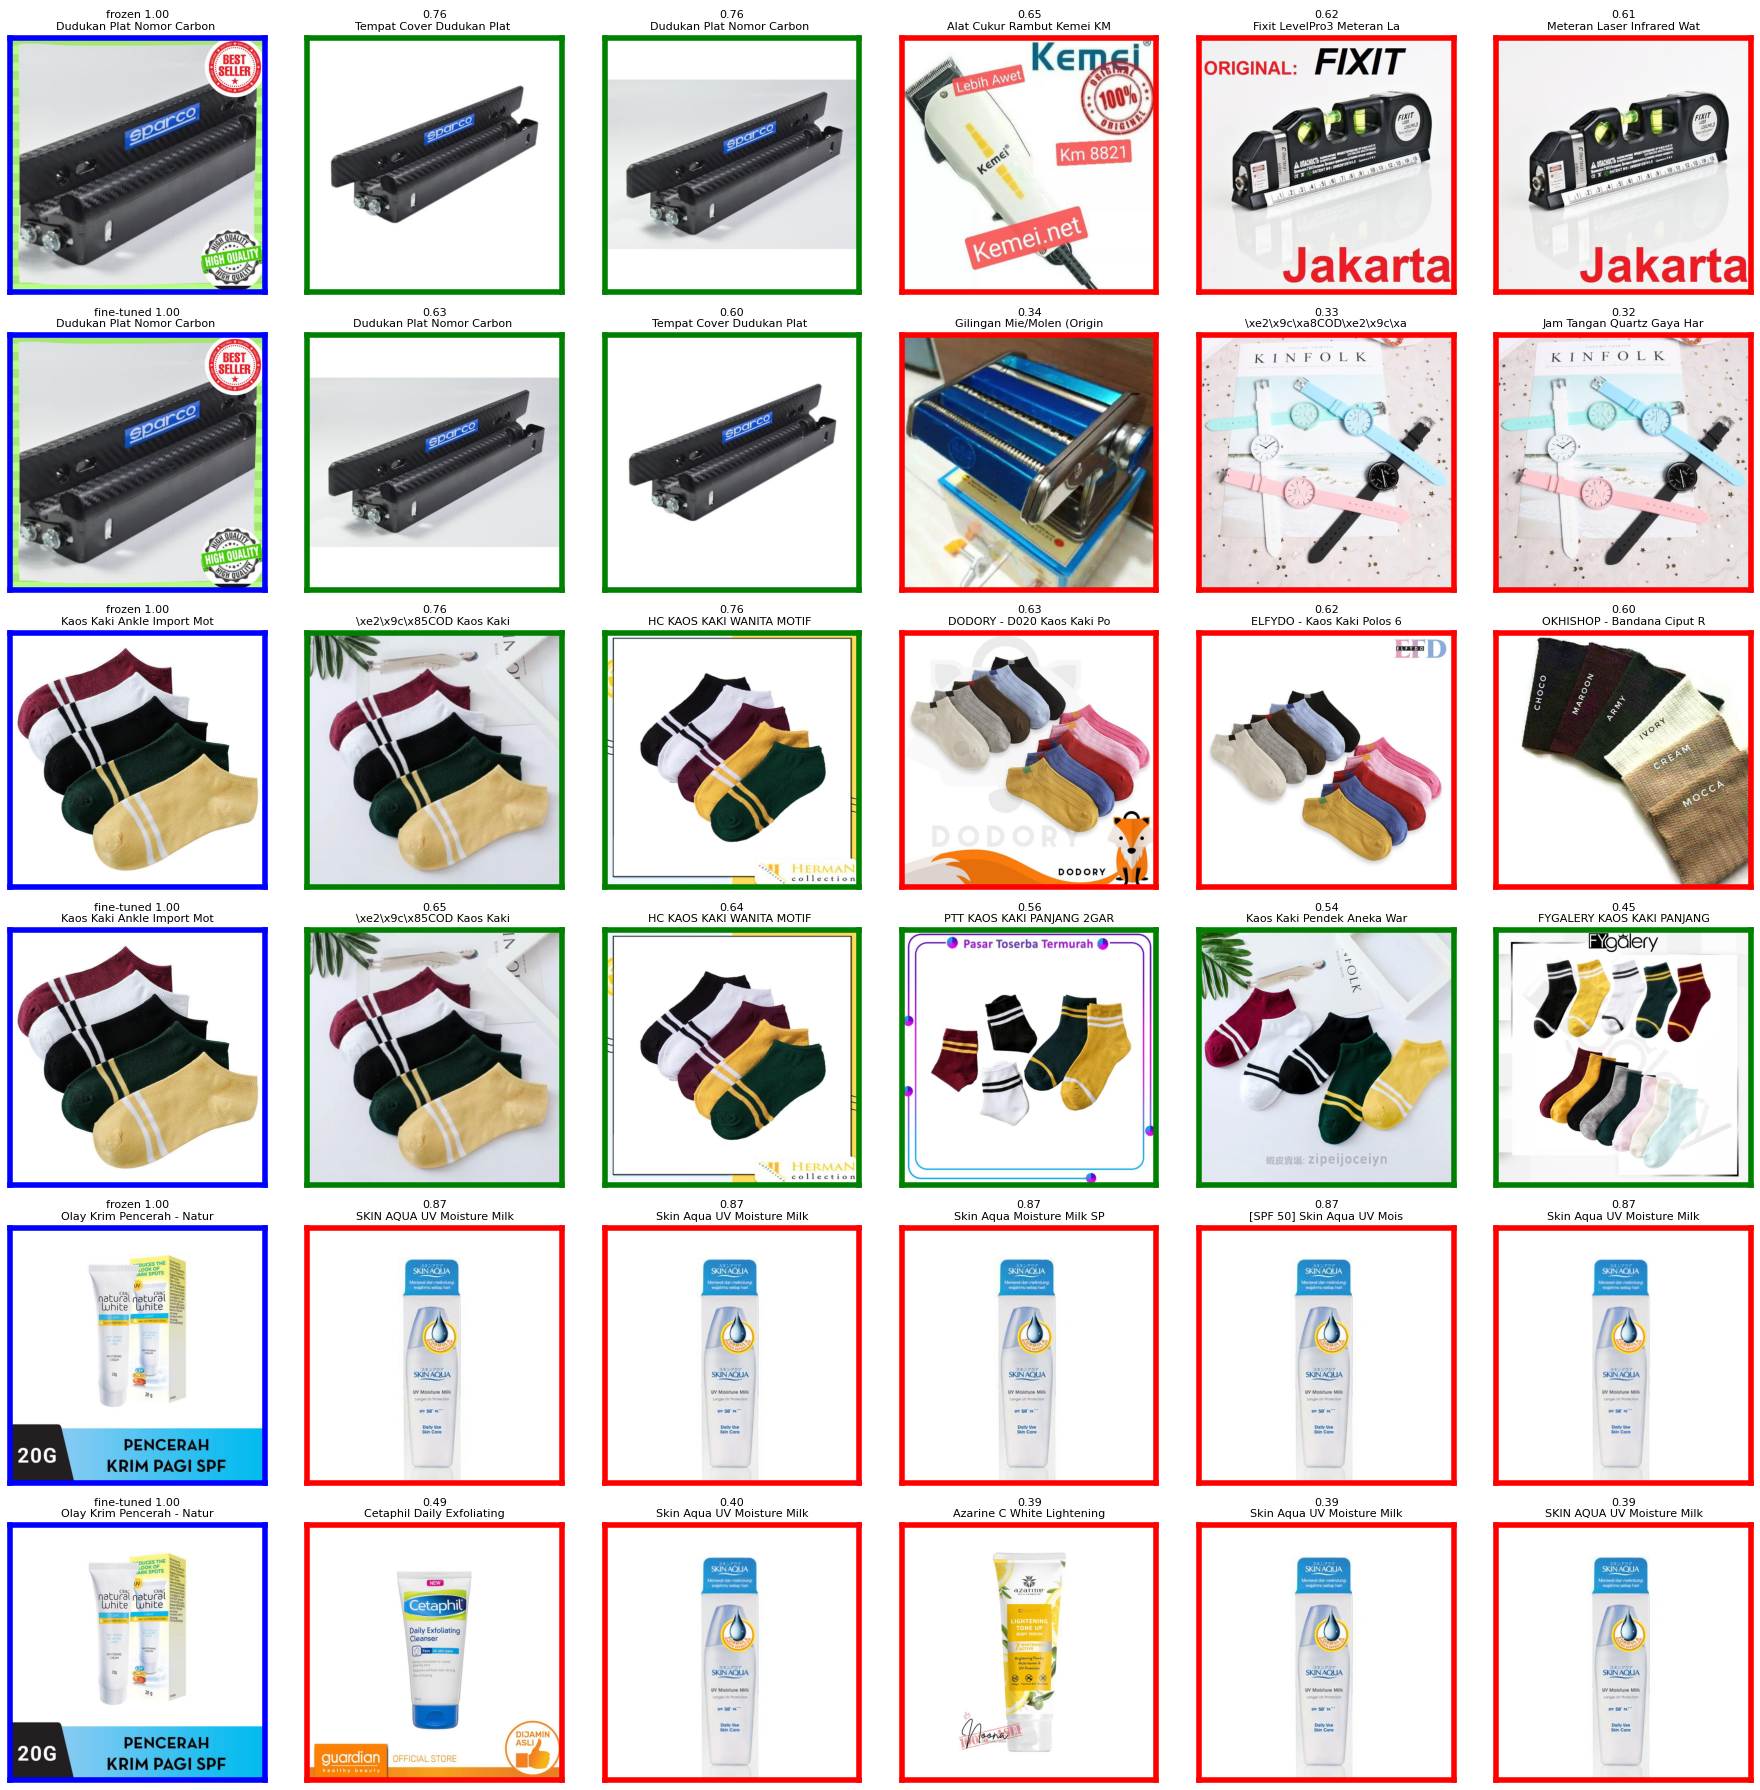

query 2538 frozen | same-product neighbours in top 5: 2 of 3 possible
query 2538 fine-tuned | same-product neighbours in top 5: 2 of 3 possible
query 2330 frozen | same-product neighbours in top 5: 2 of 5 possible
query 2330 fine-tuned | same-product neighbours in top 5: 5 of 5 possible
query 3786 frozen | same-product neighbours in top 5: 0 of 3 possible
query 3786 fine-tuned | same-product neighbours in top 5: 0 of 3 possible


In [33]:
sz = pd.Series(lab).map(pd.Series(lab).value_counts()).values
rng = np.random.default_rng(1)
queries = rng.choice(np.where(sz >= 4)[0], 3, replace=False)       # same seed as the earlier figure
models_ = [("frozen", S_img), ("fine-tuned", S_ft)]

fig, axes = plt.subplots(6, 6, figsize=(18, 18))
for qi, q in enumerate(queries):
    for mi, (name, Sx) in enumerate(models_):
        order = np.argsort(-Sx[q])[:6]                              # first is the query itself
        for c, j in enumerate(order):
            ax = axes[qi * 2 + mi, c]
            ax.imshow(Image.open(f"{BASE}/train_images/{val.image[j]}"))
            color = "blue" if j == q else ("green" if lab[j] == lab[q] else "red")
            for s in ax.spines.values(): s.set_edgecolor(color); s.set_linewidth(4)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title((name + " " if c == 0 else "") + f"{Sx[q, j]:.2f}\n{val.title[j][:26]}", fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/results/neighbours_frozen_vs_finetuned.png", dpi=130, bbox_inches="tight"); plt.show()

for q in queries:
    for name, Sx in models_:
        top = np.argsort(-Sx[q])[1:6]
        print("query", q, name, "| same-product neighbours in top 5:", int((lab[top] == lab[q]).sum()),
              "of", int(min(5, sz[q] - 1)), "possible")

## Nearest neighbours: frozen against fine-tuned (three queries)

For each of three val queries from groups with at least four listings, the
five nearest neighbours under each model. Same-product neighbours in the
top 5: frozen 4 of 11 possible, fine-tuned 7 of 11. Query 2330 accounts for
the gain (2 to 5 of 5); query 2538 is unchanged (2 of 3 for both); query 3786
finds none of its 3 partners under either model (0 of 3). Three queries is
anecdotal, not a general result.